## Multi Layer Perceptron


In [1]:
import numpy as np


class MLP:

    def __init__(self, num_inputs=3, num_hidden=[3, 5], num_outputs=2, seed=42) -> None:
        np.random.seed(seed)

        self.num_inputs = num_inputs
        self.num_hidden = num_hidden
        self.num_outputs = num_outputs

        layers = [self.num_inputs] + self.num_hidden + [self.num_outputs]

        self.weights = []
        for i in range(len(layers) - 1):
            w = np.random.rand(layers[i], layers[i + 1])
            self.weights.append(w)

    def forward_propagation(self, inputs):
        activations = inputs

        for w in self.weights:

            net_inputs = np.dot(activations, w)
            activations = self._sigmoid(net_inputs)

        return activations

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

In [2]:
mlp = MLP(seed=52, num_inputs=1000)

inputs = np.random.rand(mlp.num_inputs)

outputs = mlp.forward_propagation(inputs)

print(f"Inputs : {inputs}")
print(f"Output : {outputs}")

Inputs : [1.62984826e-01 1.04280101e-01 5.49856450e-01 3.00157712e-01
 4.31415899e-01 6.19443091e-02 2.54963921e-02 5.92570526e-01
 7.68045049e-01 1.63851469e-01 8.63129912e-01 1.30844803e-01
 2.20954593e-02 5.04849929e-01 7.81472620e-04 7.14264498e-01
 8.98359586e-01 7.23065408e-01 1.64964691e-01 1.51124716e-01
 2.73138280e-01 3.06574317e-01 6.39929284e-02 8.71527297e-01
 7.90190799e-02 7.67925509e-01 3.23997212e-01 6.51635614e-01
 8.99057921e-01 9.47567536e-01 7.94256851e-01 6.51358342e-02
 3.63924328e-01 9.44839806e-01 1.97022299e-01 9.31777661e-01
 1.90588395e-02 7.45924872e-01 6.26893292e-01 8.83962076e-01
 2.83443742e-01 1.52299286e-01 8.45084161e-01 9.67515251e-01
 8.55236770e-01 8.92785410e-01 3.64239901e-01 1.32085073e-01
 2.67241424e-01 7.38832717e-02 1.31428592e-01 6.78862682e-01
 6.17099689e-01 9.10146131e-01 5.04026831e-01 3.22339278e-01
 5.96310137e-01 3.50844953e-01 1.21901651e-01 2.89330837e-01
 5.36949786e-01 2.46375589e-01 8.84830280e-01 9.93375517e-01
 7.33873399e-02

## Backpropagation


In [3]:
import numpy as np

X = np.array([[3.0, 2.0, 10.0]])
y = np.array([[3.0]])

W1 = np.random.randn(3, 4)
b1 = np.zeros((1, 4))
W2 = np.random.randn(4, 1)
b2 = np.zeros((1, 1))

learning_rate = 0.01

z1 = np.dot(X, W1) + b1
a1 = np.maximum(0, z1)

z2 = np.dot(a1, W2) + b2
y_hat = z2

d_y_hat = 2 * (y_hat - y)

d_W2 = np.dot(a1.T, d_y_hat)
d_b2 = np.sum(d_y_hat, axis=0, keepdims=True)

d_a1 = np.dot(d_y_hat, W2.T)

d_z1 = d_a1.copy()
d_z1[z1 <= 0] = 0

d_W1 = np.dot(X.T, d_z1)
d_b1 = np.sum(d_z1, axis=0, keepdims=True)

W1 = W1 - (learning_rate * d_W1)
b1 = b1 - (learning_rate * d_b1)
W2 = W2 - (learning_rate * d_W2)
b2 = b2 - (learning_rate * d_b2)

print("One step of training complete! Weights updated.")

One step of training complete! Weights updated.


# Review


In [4]:
import pandas as pd
import numpy as np

X = pd.read_csv(
    r"C:\Users\USER\Desktop\student_id,study_hours,attendance,p.csv",
    index_col="student_id",
)

In [5]:
X

,study_hours,attendance,previous_score,assignment_score,aptitude_score,admitted
student_id,,,,,,
1,1.5,55,45,40,42,0
2,2.0,60,50,45,48,0
3,2.5,62,52,50,51,0
4,3.0,65,55,52,54,0
5,3.5,68,58,55,57,0
6,4.0,70,60,60,60,1
7,4.5,72,63,62,64,1
8,5.0,75,65,65,66,1
9,5.5,78,68,68,70,1


In [6]:
X.shape

(30, 6)

In [7]:
y = X["admitted"]
X = X.drop(columns=["admitted"])

In [8]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_train)

In [10]:
y_train.shape

(24,)

In [ ]:
# import numpy as np
# import math


# def _sigmoid(x):
#     return 1 / (1 + np.exp(-x))


# def relu(z):
#     return np.maximum(0, z)


# y_train = y_train.reshape(-1, 1)

# epochs = 200000
# lr = 0.01

# W1 = np.random.randn(5, 8)
# b1 = np.zeros((1, 8))

# W2 = np.random.randn(8, 4)
# b2 = np.zeros((1, 4))

# W3 = np.random.randn(4, 1)
# b3 = np.zeros((1, 1))

# for epoch in range(epochs):
#     z1 = np.dot(X_scaled, W1) + b1
#     a1 = relu(z1)

#     z2 = np.dot(a1, W2) + b2
#     a2 = relu(z2)

#     z3 = np.dot(a2, W3) + b3
#     a3 = _sigmoid(z3)

#     loss = np.mean(np.where(y_train == 0, -np.log(1 - a3 + 1e-8), -np.log(a3 + 1e-8)))

#     d_z3 = a3 - y_train

#     d_W3 = np.dot(a2.T, d_z3)
#     d_b3 = np.sum(d_z3, axis=0, keepdims=True)

#     d_a2 = np.dot(d_z3, W3.T)

#     d_z2 = d_a2.copy()
#     d_z2[z2 <= 0] = 0

#     d_W2 = np.dot(a1.T, d_z2)
#     d_b2 = np.sum(d_z2, axis=0, keepdims=True)

#     d_a1 = np.dot(d_z2, W2.T)

#     d_z1 = d_a1.copy()
#     d_z1[z1 <= 0] = 0

#     d_W1 = np.dot(X_scaled.T, d_z1)
#     d_b1 = np.sum(d_z1, axis=0, keepdims=True)

#     W1 = W1 - (lr * d_W1)
#     b1 = b1 - (lr * d_b1)
#     W2 = W2 - (lr * d_W2)
#     b2 = b2 - (lr * d_b2)
#     W3 = W3 - (lr * d_W3)
#     b3 = b3 - (lr * d_b3)

#     if epoch % 100 == 0:
#         print(f"Epoch : {epoch} | Loss : {loss:.4f}")


# def predict(inputs, threshold=0.5):
#     z1 = np.dot(inputs, W1) + b1
#     a1 = relu(z1)

#     z2 = np.dot(a1, W2) + b2
#     a2 = relu(z2)

#     z3 = np.dot(a2, W3) + b3
#     a3 = _sigmoid(z3)

#     return np.where(a3 > threshold, 1, 0)

In [ ]:
# from sklearn.metrics import (
#     classification_report,
#     confusion_matrix,
#     ConfusionMatrixDisplay,
# )
# import matplotlib.pyplot as plt

# X_test_scaled = scaler.transform(X_test)
# y_predict = predict(X_test_scaled)
# cls_report = classification_report(y_test, y_predict)
# cm = confusion_matrix(y_test, y_predict)
# ConfusionMatrixDisplay(cm).plot(cmap="Blues")
# plt.show()

# print(cls_report)

In [13]:
import numpy as np


class ReLU:
    @staticmethod
    def forward(z):
        return np.maximum(0, z)


class Sigmoid:
    @staticmethod
    def forward(z):
        return 1 / (1 + np.exp(-z))


class NN:
    def __init__(
        self,
        num_inputs: int,
        num_hidden: list[int],
        num_output: int = 1,
        seed: int = 42,
        learning_rate: float = 0.01,
        epochs: int = 1000,
        threshold: float = 0.5,
    ) -> None:
        np.random.seed(seed)

        self.num_inputs = num_inputs
        self.num_hidden = num_hidden
        self.num_output = num_output
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.threshold = threshold

        layers = [num_inputs] + num_hidden + [num_output]

        self.weights = []
        self.bias = []

        for i in range(len(layers) - 1):
            w = np.random.randn(layers[i], layers[i + 1]) * np.sqrt(2 / layers[i])
            b = np.zeros((1, layers[i + 1]))
            self.weights.append(w)
            self.bias.append(b)

        self.activation_funcs = [ReLU] * (len(self.weights) - 1) + [Sigmoid]

    def predict(self, input):
        a = input

        for i, w in enumerate(self.weights):
            z = np.dot(a, w) + self.bias[i]
            a = self.activation_funcs[i].forward(z)

        return np.where(a >= self.threshold, 1, 0)

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).reshape(-1, 1)

        for epoch in range(self.epochs):
            a = X
            Z = []
            A = [X]
            for i, w in enumerate(self.weights):
                z = np.dot(a, w) + self.bias[i]
                a = self.activation_funcs[i].forward(z)
                Z.append(z)
                A.append(a)

            loss = np.mean(np.where(y == 0, -np.log(1 - a + 1e-8), -np.log(a + 1e-8)))

            for i in range(len(Z) - 1, -1, -1):
                if i == len(Z) - 1:
                    d_z = A[-1] - y
                else:
                    d_a = np.dot(d_z, self.weights[i + 1].T)
                    d_z = d_a * (Z[i] > 0)

                d_W = np.dot(A[i].T, d_z)
                d_b = np.sum(d_z, axis=0, keepdims=True)

                self.weights[i] -= self.learning_rate * d_W
                self.bias[i] -= self.learning_rate * d_b

            if (epoch + 1) % 100 == 0:
                print(f"Epoch : {epoch + 1} | Loss : {loss:.4f}")
        if (epoch + 1) % 100 != 0:
            print(f"Epoch : {epoch + 1} | Loss : {loss:.4f}")

In [14]:
nn = NN(5, [8, 4, 2], 1, epochs=2000)
nn.fit(X_scaled, y_train)

Epoch : 100 | Loss : 0.6897
Epoch : 200 | Loss : 0.6897
Epoch : 300 | Loss : 0.6897
Epoch : 400 | Loss : 0.6897
Epoch : 500 | Loss : 0.6897
Epoch : 600 | Loss : 0.6897
Epoch : 700 | Loss : 0.6897
Epoch : 800 | Loss : 0.6897
Epoch : 900 | Loss : 0.6897
Epoch : 1000 | Loss : 0.6897
Epoch : 1100 | Loss : 0.6897
Epoch : 1200 | Loss : 0.6897
Epoch : 1300 | Loss : 0.6897
Epoch : 1400 | Loss : 0.6897
Epoch : 1500 | Loss : 0.6897
Epoch : 1600 | Loss : 0.6897
Epoch : 1700 | Loss : 0.6897
Epoch : 1800 | Loss : 0.6897
Epoch : 1900 | Loss : 0.6897
Epoch : 2000 | Loss : 0.6897


c:\Users\USER\.conda\envs\ml-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\.conda\envs\ml-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\.conda\envs\ml-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


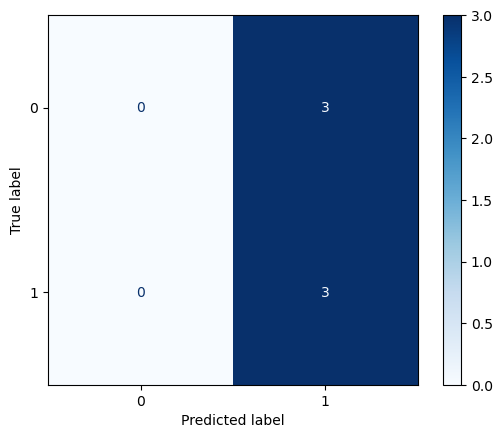

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.50      1.00      0.67         3

    accuracy                           0.50         6
   macro avg       0.25      0.50      0.33         6
weighted avg       0.25      0.50      0.33         6



In [15]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

X_test_scaled = scaler.transform(X_test)
y_predict = nn.predict(X_test_scaled)
cls_report = classification_report(y_test, y_predict)
cm = confusion_matrix(y_test, y_predict)
ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.show()

print(cls_report)